### 2026-03-12 temporal variance

Compare temporal variance (here defined as scale of daily anomalies from monthly means) over a year in the AIMIP submissions, compared to ERA5 reference.

In [1]:
import xarray as xr
import numpy as np
import os
from dask.diagnostics import ProgressBar
from cartopy import crs as ccrs
from matplotlib import pyplot as plt

from aimip_data_utils import (
    AIMIP_EXPERIMENT_SUBMISSIONS,
    ExperimentSubmission,
    EVALUATION_VARIABLES,
    open_aimip_data,
    ERA5_1DEG,
    add_latlon_to_dlesym,
    regrid_dataset,
    transfer_attrs,
    convert_tdas_to_huss,
    compute_rms,
    compute_weighted_mean,
    CATEGORICAL_COLORS,
)

In [2]:
def compute_daily_anomaly_std(
    daily_data: xr.Dataset,
    monthly_data: xr.Dataset,
    eval_vars: list[str],
    keep_varnames: list[str],
    time_dim: str='time'
) -> xr.Dataset:
    monthly_on_daily = monthly_data.reindex({time_dim: daily_data[time_dim]}, method='ffill')
    daily_anomaly_std = (daily_data[eval_vars] - monthly_on_daily[eval_vars]).std(time_dim)
    for var in keep_varnames:
        if var in daily_data.data_vars:
            daily_anomaly_std[var] = daily_data[var]
    daily_anomaly_std = transfer_attrs(daily_data, daily_anomaly_std)
    for var in eval_vars:
        daily_anomaly_std[var] = daily_anomaly_std[var].assign_attrs(
            {
                'long_name': f"{daily_anomaly_std[var].attrs.get('long_name', var)} daily variability"
            }
        )
    return daily_anomaly_std

In [3]:
LATITUDE_LIMITS = (-87.5, 87.5) # avoid regridding artifacts at the poles
OUTDIR = os.environ.get('AIMIP_FIGURES_DIR', './figures')
CACHE_DIR = os.environ.get('AIMIP_CACHE_DIR', './cached')
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
DAILY_TIME_SLICE = slice('1979-01-01', '1979-12-31')
RESET_CACHE = True
RESTORE_CACHE = False

In [4]:
daily_data, missing_files_daily = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='day',
    time_period='daily_first_15_months',
)

ACE2.1-ERA5
specific_humidity
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/day/hus/gr/v20251130/hus_day_ACE2-ERA5_aimip_r1i1p1f1_gr_19781001-19791231.nc
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/day/hus/gr/v20251130/hus_day_ACE2-ERA5_aimip_r2i1p1f1_gr_19781001-19791231.nc
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/day/hus/gr/v20251130/hus_day_ACE2-ERA5_aimip_r3i1p1f1_gr_19781001-19791231.nc
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/day/hus/gr/v20251130/hus_day_ACE2-ERA5_aimip_r4i1p1f1_gr_19781001-19791231.nc
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/day/hus/gr/v20251130/hus_day_ACE2-ERA5_aimip_r5i1p1f1_gr_19781001-19791231.nc
surface_specific_humidity
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/day/huss/gn/v20251130/huss_day_ACE2-ERA5_aimip_r1i1p1f1_gn_19781001-19791231.nc
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/day/huss/gn/v20251130/huss_day_ACE2-ERA5_aimip_r2i1p1f1_gn_19781001-19791231.nc
~/dev/AIMIP/loca

/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [5]:
missing_files_daily

{'ACE2.1-ERA5': ['~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/day/tdas/gr/v20251130/tdas_day_ACE2-ERA5_aimip_r1i1p1f1_gr_19781001-19791231.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/day/tdas/gr/v20251130/tdas_day_ACE2-ERA5_aimip_r2i1p1f1_gr_19781001-19791231.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/day/tdas/gr/v20251130/tdas_day_ACE2-ERA5_aimip_r3i1p1f1_gr_19781001-19791231.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/day/tdas/gr/v20251130/tdas_day_ACE2-ERA5_aimip_r4i1p1f1_gr_19781001-19791231.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/day/tdas/gr/v20251130/tdas_day_ACE2-ERA5_aimip_r5i1p1f1_gr_19781001-19791231.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/day/psl/gr/v20251130/psl_day_ACE2-ERA5_aimip_r1i1p1f1_gr_19781001-19791231.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/day/psl/gr/v20251130/psl_day_ACE2-ERA5_aimip_r2i1p1f1_gr_19781001-19791231.nc',
  '~/dev/AIMIP/l

In [6]:
for experiment_submission_name, dataset in daily_data.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    daily_data[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD1.5 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [8]:
ERA5_DAILY_DATA_PATH = '~/dev/AIMIP/local_data/ERA5/day_1deg/ERA5_daily_1deg_19781001-19791231.nc'
era5_daily_1deg = xr.open_dataset(ERA5_DAILY_DATA_PATH, chunks={}).rename({'latitude': 'lat', 'longitude': 'lon'})

In [9]:
monthly_data, missing_files_monthly = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)

ACE2.1-ERA5
specific_humidity
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r3i1p1f1_gr_197810-202412.nc
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r4i1p1f1_gr_197810-202412.nc
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r5i1p1f1_gr_197810-202412.nc
surface_specific_humidity
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
~/dev/AIMIP/local_data/Ai2/ACE

In [10]:
missing_files_monthly

{'ACE2.1-ERA5': ['~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r3i1p1f1_gr_197810-202412.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r4i1p1f1_gr_197810-202412.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r5i1p1f1_gr_197810-202412.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/psl/gr/v20251130/psl_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc',
  '~/dev/AIMIP/local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/psl/gr/v20251130/psl_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc',
  '~/dev/AIMIP/local_data/Ai2/

In [11]:
for experiment_submission_name, dataset in monthly_data.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD1.5 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [12]:
era5_monthly_1deg, _ = open_aimip_data(
    [ERA5_1DEG],
    EVALUATION_VARIABLES,
    table='Amon',
    n_realizations=1,
)
era5_monthly_1deg = (
    era5_monthly_1deg['ERA5']
    .isel(realization=0).squeeze().drop_vars('realization')
    .drop_vars(['forecast_period', 'originating_centre'])
)

ERA5
specific_humidity
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_hus_1978-2024.nc
surface_specific_humidity
Not found: ~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_huss_1978-2024.nc
dew_point_temperature
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_tdas_1978-2024.nc
precipitation_flux
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_pr_1978-2024.nc
surface_air_pressure
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ps_1978-2024.nc
air_pressure_at_sea_level
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_psl_1978-2024.nc
air_temperature
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ta_1978-2024.nc
air_temperature
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_tas_1978-2024.nc
surface_temperature
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ts_1978-2024.nc
eastward_wind


/home/brianhenn/dev/AIMIP/.claude/worktrees/e4-figure-update/evaluations/notebooks/aimip_data_utils.py:619: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  variable_dataset = xr.open_dataset(path, chunks={})
/home/brianhenn/dev/AIMIP/.claude/worktrees/e4-figure-update/evaluations/notebooks/aimip_data_utils.py:619: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'unit

~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_ua_1978-2024.nc
eastward_wind
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_uas_1978-2024.nc
northward_wind
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_va_1978-2024.nc
northward_wind
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_vas_1978-2024.nc
geopotential_height
~/dev/AIMIP/local_data/ERA5/mon_1deg/native6_ERA5_an_v1_Amon_zg_1978-2024.nc


/home/brianhenn/dev/AIMIP/.claude/worktrees/e4-figure-update/evaluations/notebooks/aimip_data_utils.py:619: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  variable_dataset = xr.open_dataset(path, chunks={})
/home/brianhenn/dev/AIMIP/.claude/worktrees/e4-figure-update/evaluations/notebooks/aimip_data_utils.py:619: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'unit

In [13]:
era5_monthly_1deg = convert_tdas_to_huss(era5_monthly_1deg)

Converting 'tdas' to 'huss'.


In [14]:
shared_submission_keys = set(daily_data.keys()).intersection(monthly_data.keys())
shared_submissions = []
for key in shared_submission_keys:
    if len(daily_data[key].data_vars) > 0 and len(monthly_data[key].data_vars) > 0:
        shared_submissions.append(key)
shared_submissions = sorted(shared_submissions, key=lambda x: x.lower())
eval_varnames = [eval_var.short_name for eval_var in EVALUATION_VARIABLES]
eval_varnames.remove('tdas')
keep_varnames = ['lat_bnds', 'lon_bnds']
daily_anomaly_std = {}
for shared_submission in shared_submissions:
    print(shared_submission)
    monthly_time = monthly_data[shared_submission].time
    monthly_time_beginning = monthly_time.astype("datetime64[M]").astype(monthly_time.dtype)
    available_eval_vars = (
        set(eval_varnames)
        .intersection(daily_data[shared_submission].data_vars)
        .intersection(monthly_data[shared_submission].data_vars)
    )
    print(available_eval_vars)
    daily_anomaly_std[shared_submission] = compute_daily_anomaly_std(
        daily_data[shared_submission].sel(time=DAILY_TIME_SLICE),
        monthly_data[shared_submission].assign_coords(
            {
                'time': monthly_time_beginning
            }
        ),
        available_eval_vars,
        keep_varnames,
    )

ACE2.1-ERA5
{'tas', 'va', 'ps', 'huss', 'vas', 'pr', 'ta', 'ua', 'uas', 'ts', 'zg', 'hus'}
ArchesWeather-V2
{'tas', 'psl', 'va', 'vas', 'ta', 'ua', 'uas', 'ts', 'zg', 'hus'}
ArchesWeatherGen-V2
{'tas', 'psl', 'va', 'vas', 'ta', 'ua', 'uas', 'ts', 'zg', 'hus'}
cBottle1.3
{'tas', 'psl', 'va', 'huss', 'pr', 'ta', 'ua', 'uas', 'vas', 'zg', 'hus'}
DLESyM
{'zg', 'tas', 'ta'}
NeuralGCM
{'tas', 'va', 'ps', 'huss', 'vas', 'pr', 'ta', 'ua', 'uas', 'ts', 'zg', 'hus'}
NeuralGCM-HRD
{'tas', 'va', 'ps', 'huss', 'vas', 'pr', 'ta', 'ua', 'uas', 'ts', 'zg', 'hus'}


In [15]:
# add coordinates to DLESyM
daily_anomaly_std['DLESyM'] = add_latlon_to_dlesym(daily_anomaly_std['DLESyM']).drop_vars('i', errors='ignore')

In [16]:
for k, v in daily_anomaly_std.items():
    print(k)
    with ProgressBar():
        daily_anomaly_std[k] = v.compute()

ACE2.1-ERA5
[########################################] | 100% Completed | 239.16 s
ArchesWeather-V2
[########################################] | 100% Completed | 173.71 s
ArchesWeatherGen-V2
[########################################] | 100% Completed | 161.28 s
cBottle1.3
[########################################] | 100% Completed | 220.16 s
DLESyM
[########################################] | 100% Completed | 11.61 s
NeuralGCM
[########################################] | 100% Completed | 41.80 s
NeuralGCM-HRD
[########################################] | 100% Completed | 70.27 s


In [17]:
available_eval_vars_era5 = (
    set(eval_varnames)
    .intersection(era5_daily_1deg.data_vars)
    .intersection(era5_monthly_1deg.data_vars)
)
print(available_eval_vars_era5)
era5_monthly_starts = era5_monthly_1deg.time.astype("datetime64[M]").astype(era5_monthly_1deg.time.dtype)
era5_monthly_1deg_reindexed = (
    era5_monthly_1deg
    .assign_coords({'time': era5_monthly_starts})
    .interp({'lat': era5_daily_1deg.lat})
)
daily_anomaly_std_era5 = compute_daily_anomaly_std(
    era5_daily_1deg.sel(time=DAILY_TIME_SLICE),
    era5_monthly_1deg_reindexed,
    available_eval_vars_era5,
    keep_varnames,
)

{'tas', 'psl', 'va', 'ps', 'huss', 'vas', 'pr', 'ta', 'ua', 'uas', 'ts', 'zg', 'hus'}


In [18]:
with ProgressBar():
    daily_anomaly_std_era5 = daily_anomaly_std_era5.compute()

[########################################] | 100% Completed | 112.72 s


In [62]:
# Compute time-mean precipitation for each submission (denominator for CV error)
time_mean_pr = {}
for shared_submission in shared_submissions:
    if 'pr' not in daily_anomaly_std[shared_submission].data_vars:
        continue
    pr_mean = monthly_data[shared_submission]['pr'].sel(time=DAILY_TIME_SLICE).mean('time')
    ds = pr_mean.to_dataset(name='pr')
    for var in keep_varnames:
        if var in daily_anomaly_std[shared_submission].data_vars:
            ds[var] = daily_anomaly_std[shared_submission][var]
    time_mean_pr[shared_submission] = transfer_attrs(monthly_data[shared_submission], ds)

# ERA5 time-mean precipitation
# Use era5_monthly_1deg (AIMIP-format, proper CF attrs and lat_bnds/lon_bnds) as the source
if 'pr' in daily_anomaly_std_era5.data_vars and 'pr' in era5_monthly_1deg.data_vars:
    time_mean_pr_era5 = era5_monthly_1deg['pr'].sel(time=DAILY_TIME_SLICE).mean('time').to_dataset(name='pr')
    for var in keep_varnames:
        if var in era5_monthly_1deg.data_vars:
            time_mean_pr_era5[var] = era5_monthly_1deg[var]
    time_mean_pr_era5 = transfer_attrs(era5_monthly_1deg, time_mean_pr_era5)

In [63]:
regridded_1deg_daily_anomaly_stds = []
experiment_submissions_1deg = list(daily_anomaly_std.keys())
experiment_submissions_1deg.remove('NeuralGCM') # don't evaluate 2.8 deg at 1 deg
for experiment_submission_name in experiment_submissions_1deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else: 
        # for HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    # destination grid is 1deg ACE
    destination_grid = (
        daily_anomaly_std['ACE2.1-ERA5']
        .sel(lat=slice(*LATITUDE_LIMITS))
        .isel(realization=0)
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_1deg_daily_anomaly_std = regrid_dataset(
        daily_anomaly_std[experiment_submission_name],
        destination_grid,
        sample_dims=['realization'],
        **regridder_kwargs
    )
    regridded_1deg_daily_anomaly_stds.append(
        regridded_1deg_daily_anomaly_std.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_1deg_daily_anomaly_stds = xr.concat(
    regridded_1deg_daily_anomaly_stds,
    dim='experiment_submission',
    join='outer',
    combine_attrs='override',
    coords='minimal',
)

ACE2.1-ERA5
ArchesWeather-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


cBottle1.3


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:76: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lon = ds.cf['longitude']
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:77: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lat = ds.cf['latitude']


DLESyM
NeuralGCM-HRD


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

In [64]:
# put empty MD1.5 back in for plotting purposes
regridded_1deg_daily_anomaly_stds = xr.concat(
    [
        regridded_1deg_daily_anomaly_stds,
        xr.Dataset().expand_dims({'experiment_submission': ['MD1.5']})
    ], dim='experiment_submission', join='outer'
)
output_names = sorted([str(name) for name in regridded_1deg_daily_anomaly_stds.experiment_submission.values], key=lambda x: x.lower())
regridded_1deg_daily_anomaly_stds = regridded_1deg_daily_anomaly_stds.sel(experiment_submission=output_names)
# Propagate model variable attrs to ERA5 so 1deg/2.8deg regrids inherit them.
daily_anomaly_std_era5 = transfer_attrs(regridded_1deg_daily_anomaly_stds, daily_anomaly_std_era5)

In [65]:
# regrid 1deg ERA5 to 1deg ACE grid
destination_grid = (
        daily_anomaly_std['ACE2.1-ERA5']
        .sel(lat=slice(*LATITUDE_LIMITS))
        .isel(realization=0)
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
regridded_1deg_daily_anomaly_std_era5 = regrid_dataset(
    daily_anomaly_std_era5,
    destination_grid,
    sample_dims=[],
    method='conservative',
)

In [66]:
# Regrid monthly mean precipitation to 1deg grid
regridded_1deg_time_means_pr = []
for experiment_submission_name in experiment_submissions_1deg:
    if experiment_submission_name not in time_mean_pr:
        continue
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else:
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    destination_grid = (
        daily_anomaly_std['ACE2.1-ERA5']
        .sel(lat=slice(*LATITUDE_LIMITS))
        .isel(realization=0)
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded = regrid_dataset(
        time_mean_pr[experiment_submission_name],
        destination_grid,
        sample_dims=['realization'],
        **regridder_kwargs
    )
    regridded_1deg_time_means_pr.append(
        regridded.expand_dims({'experiment_submission': [experiment_submission_name]})
    )
regridded_1deg_time_means_pr = xr.concat(
    regridded_1deg_time_means_pr,
    dim='experiment_submission', join='outer', combine_attrs='override', coords='minimal',
)

# Regrid ERA5 monthly mean precipitation to 1deg grid
destination_grid = (
    daily_anomaly_std['ACE2.1-ERA5']
    .sel(lat=slice(*LATITUDE_LIMITS))
    .isel(realization=0)
    [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
)
regridded_1deg_time_mean_pr_era5 = regrid_dataset(
    time_mean_pr_era5, destination_grid, sample_dims=[], method='conservative',
)
with ProgressBar():
    regridded_1deg_time_means_pr = regridded_1deg_time_means_pr.compute()
with ProgressBar():
    regridded_1deg_time_mean_pr_era5 = regridded_1deg_time_mean_pr_era5.compute()

/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:76: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lon = ds.cf['longitude']
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:77: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lat = ds.cf['latitude']


[########################################] | 100% Completed | 5.78 sms
[########################################] | 100% Completed | 403.67 ms


In [67]:
regridded_2p8deg_daily_anomaly_stds = []
experiment_submissions_2p8deg = list(daily_anomaly_std.keys())
experiment_submissions_2p8deg.remove('NeuralGCM-HRD') # don't evaluate 1 deg at 2.8 deg
for experiment_submission_name in experiment_submissions_2p8deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else: 
        # for HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    # destination grid is 2p8deg NeuralGCM
    destination_grid = (
        daily_anomaly_std['NeuralGCM']
        .isel(realization=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_2p8deg_daily_anomaly_std = regrid_dataset(
        daily_anomaly_std[experiment_submission_name],
        destination_grid,
        sample_dims=['realization'],
        **regridder_kwargs
    )
    regridded_2p8deg_daily_anomaly_stds.append(
        regridded_2p8deg_daily_anomaly_std.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_2p8deg_daily_anomaly_stds = xr.concat(
    regridded_2p8deg_daily_anomaly_stds,
    dim='experiment_submission',
    join='outer',
    combine_attrs='override',
    coords='minimal',
)

ACE2.1-ERA5
ArchesWeather-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


cBottle1.3
DLESyM


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:76: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lon = ds.cf['longitude']
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:77: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lat = ds.cf['latitude']


NeuralGCM


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

In [68]:
# put empty MD1.5 back in for plotting purposes
regridded_2p8deg_daily_anomaly_stds = xr.concat(
    [
        regridded_2p8deg_daily_anomaly_stds,
        xr.Dataset().expand_dims({'experiment_submission': ['MD1.5']})
    ], dim='experiment_submission', join='outer'
)
output_names = sorted([str(name) for name in regridded_2p8deg_daily_anomaly_stds.experiment_submission.values], key=lambda x: x.lower())
regridded_2p8deg_daily_anomaly_stds = regridded_2p8deg_daily_anomaly_stds.sel(experiment_submission=output_names)

In [69]:
# regrid 1deg ERA5 to 2.8 deg NeuralGCM
destination_grid = (
        daily_anomaly_std['NeuralGCM']
        .sel(lat=slice(*LATITUDE_LIMITS))
        .isel(realization=0)
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
regridded_2p8deg_daily_anomaly_std_era5 = regrid_dataset(
    daily_anomaly_std_era5,
    destination_grid,
    sample_dims=[],
    method='conservative',
)

In [70]:
# Regrid monthly mean precipitation to 2.8deg grid
regridded_2p8deg_time_means_pr = []
for experiment_submission_name in experiment_submissions_2p8deg:
    if experiment_submission_name not in time_mean_pr:
        continue
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else:
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    destination_grid = (
        daily_anomaly_std['NeuralGCM']
        .isel(realization=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded = regrid_dataset(
        time_mean_pr[experiment_submission_name],
        destination_grid,
        sample_dims=['realization'],
        **regridder_kwargs
    )
    regridded_2p8deg_time_means_pr.append(
        regridded.expand_dims({'experiment_submission': [experiment_submission_name]})
    )
regridded_2p8deg_time_means_pr = xr.concat(
    regridded_2p8deg_time_means_pr,
    dim='experiment_submission', join='outer', combine_attrs='override', coords='minimal',
)

# Regrid ERA5 monthly mean precipitation to 2.8deg grid
destination_grid = (
    daily_anomaly_std['NeuralGCM']
    .sel(lat=slice(*LATITUDE_LIMITS))
    .isel(realization=0)
    [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
)
regridded_2p8deg_time_mean_pr_era5 = regrid_dataset(
    time_mean_pr_era5, destination_grid, sample_dims=[], method='conservative',
)
with ProgressBar():
    regridded_2p8deg_time_means_pr = regridded_2p8deg_time_means_pr.compute()
with ProgressBar():
    regridded_2p8deg_time_mean_pr_era5 = regridded_2p8deg_time_mean_pr_era5.compute()

/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:76: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lon = ds.cf['longitude']
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:77: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lat = ds.cf['latitude']


[########################################] | 100% Completed | 5.77 sms
[########################################] | 100% Completed | 403.77 ms


In [78]:
if RESET_CACHE:
    path_1deg = os.path.join(CACHE_DIR, 'regridded_1deg_daily_anomaly_stds.nc')
    path_1deg_era5 = os.path.join(CACHE_DIR, 'regridded_1deg_daily_anomaly_std_era5.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'regridded_2p8deg_daily_anomaly_stds.nc')
    path_2p8deg_era5 = os.path.join(CACHE_DIR, 'regridded_2p8deg_daily_anomaly_std_era5.nc')
    path_1deg_time_pr = os.path.join(CACHE_DIR, 'regridded_1deg_time_means_pr.nc')
    path_1deg_time_pr_era5 = os.path.join(CACHE_DIR, 'regridded_1deg_time_mean_pr_era5.nc')
    path_2p8deg_time_pr = os.path.join(CACHE_DIR, 'regridded_2p8deg_time_means_pr.nc')
    path_2p8deg_time_pr_era5 = os.path.join(CACHE_DIR, 'regridded_2p8deg_time_mean_pr_era5.nc')
    try:
        os.remove(path_1deg)
        os.remove(path_1deg_era5)
        os.remove(path_2p8deg)
        os.remove(path_2p8deg_era5)
        os.remove(path_1deg_time_pr)
        os.remove(path_1deg_time_pr_era5)
        os.remove(path_2p8deg_time_pr)
        os.remove(path_2p8deg_time_pr_era5)
    except FileNotFoundError:
        print("Nothing deleted from cache.")
    regridded_1deg_daily_anomaly_stds.to_netcdf(path_1deg)
    regridded_1deg_daily_anomaly_std_era5.to_netcdf(path_1deg_era5)
    regridded_2p8deg_daily_anomaly_stds.to_netcdf(path_2p8deg)
    regridded_2p8deg_daily_anomaly_std_era5.to_netcdf(path_2p8deg_era5)
    regridded_1deg_time_means_pr.to_netcdf(path_1deg_time_pr)
    regridded_1deg_time_mean_pr_era5.to_netcdf(path_1deg_time_pr_era5)
    regridded_2p8deg_time_means_pr.to_netcdf(path_2p8deg_time_pr)
    regridded_2p8deg_time_mean_pr_era5.to_netcdf(path_2p8deg_time_pr_era5)
    print("Cache updated.")

Cache updated.


In [79]:
if RESTORE_CACHE: 
    print("Cache restored.")
    path_1deg = os.path.join(CACHE_DIR, 'regridded_1deg_daily_anomaly_stds.nc')
    path_1deg_era5 = os.path.join(CACHE_DIR, 'regridded_1deg_daily_anomaly_std_era5.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'regridded_2p8deg_daily_anomaly_stds.nc')
    path_2p8deg_era5 = os.path.join(CACHE_DIR, 'regridded_2p8deg_daily_anomaly_std_era5.nc')
    path_1deg_time_pr = os.path.join(CACHE_DIR, 'regridded_1deg_time_means_pr.nc')
    path_1deg_time_pr_era5 = os.path.join(CACHE_DIR, 'regridded_1deg_time_mean_pr_era5.nc')
    path_2p8deg_time_pr = os.path.join(CACHE_DIR, 'regridded_2p8deg_time_means_pr.nc')
    path_2p8deg_time_pr_era5 = os.path.join(CACHE_DIR, 'regridded_2p8deg_time_mean_pr_era5.nc')
    regridded_1deg_daily_anomaly_stds = xr.open_dataset(path_1deg)
    regridded_1deg_daily_anomaly_std_era5 = xr.open_dataset(path_1deg_era5)
    regridded_2p8deg_daily_anomaly_stds = xr.open_dataset(path_2p8deg)
    regridded_2p8deg_daily_anomaly_std_era5 = xr.open_dataset(path_2p8deg_era5)
    regridded_1deg_time_means_pr = xr.open_dataset(path_1deg_time_pr)
    regridded_1deg_time_mean_pr_era5 = xr.open_dataset(path_1deg_time_pr_era5)
    regridded_2p8deg_time_means_pr = xr.open_dataset(path_2p8deg_time_pr)
    regridded_2p8deg_time_mean_pr_era5 = xr.open_dataset(path_2p8deg_time_pr_era5)

In [80]:
# Relative error for all variables
error_1deg = regridded_1deg_daily_anomaly_stds / regridded_1deg_daily_anomaly_std_era5 - 1
error_1deg = transfer_attrs(regridded_1deg_daily_anomaly_stds, error_1deg)
error_2p8deg = regridded_2p8deg_daily_anomaly_stds / regridded_2p8deg_daily_anomaly_std_era5 - 1
error_2p8deg = transfer_attrs(regridded_2p8deg_daily_anomaly_stds, error_2p8deg)

# Override pr with coefficient of daily variability error:
# (model_std / model_monthly_mean) - (ERA5_std / ERA5_monthly_mean)
if 'pr' in error_1deg.data_vars:
    cv_era5_1deg = regridded_1deg_daily_anomaly_std_era5['pr'] / regridded_1deg_time_mean_pr_era5['pr']
    cv_model_1deg = regridded_1deg_daily_anomaly_stds['pr'] / regridded_1deg_time_means_pr['pr']
    error_1deg['pr'] = cv_model_1deg - cv_era5_1deg

if 'pr' in error_2p8deg.data_vars:
    cv_era5_2p8deg = regridded_2p8deg_daily_anomaly_std_era5['pr'] / regridded_2p8deg_time_mean_pr_era5['pr']
    cv_model_2p8deg = regridded_2p8deg_daily_anomaly_stds['pr'] / regridded_2p8deg_time_means_pr['pr']
    error_2p8deg['pr'] = cv_model_2p8deg - cv_era5_2p8deg

In [81]:
gm_error_1deg = compute_weighted_mean(error_1deg)
gm_error_1deg = transfer_attrs(regridded_1deg_daily_anomaly_stds, gm_error_1deg)
gm_error_2p8deg = compute_weighted_mean(error_2p8deg)
gm_error_2p8deg = transfer_attrs(regridded_2p8deg_daily_anomaly_stds, gm_error_2p8deg)

In [82]:
map_vars = ['tas', 'ts', 'pr', 'huss', 'zg', 'AT850', 'AT100', 'Q850', 'U850', 'V850']

def get_varname_indexer(var: str) -> tuple[str, dict[str, float]]:
    if var in ['tas', 'ts', 'pr', 'huss', 'zg']:
        return var, {}
    elif var.startswith('Q'):
        return 'hus', {'plev': [85000.]}
    elif var.startswith('U'):
        return 'ua', {'plev': [85000.]}
    elif var.startswith('V'):
        return 'va', {'plev': [85000.]}
    elif var.startswith('AT'):
        if var.endswith('100'):
            return 'ta', {'plev': [10000.]}
        else:
            return 'ta', {'plev': [85000.]}

def error_label(varname: str) -> str:
    return 'cv error [-]' if varname == 'pr' else 'relative error [-]'

In [ ]:
combined_regridded_1deg_daily_anomaly_stds = xr.concat(
    [
        regridded_1deg_daily_anomaly_stds,
        regridded_1deg_daily_anomaly_std_era5.expand_dims({'experiment_submission': ['ERA5']})
    ],
    dim='experiment_submission',
    join='inner'
)

for var in map_vars:
    print(var)
    varname, indexer = get_varname_indexer(var)
    plottable = combined_regridded_1deg_daily_anomaly_stds.sel(**indexer).isel(realization=0)[varname]
    vmin = plottable.quantile(0.02)
    vmax = plottable.quantile(0.98)
    fg = plottable.plot(
        col='experiment_submission', vmin=vmin, vmax=vmax,
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        figsize=(16, 4),
        cbar_kwargs=dict(
            label=(
                f'{error_1deg[varname].attrs.get("long_name", varname)} '
                f'[{error_1deg[varname].attrs.get("units", "-")}]'
            ),
            orientation='horizontal',
            aspect=50,
        ),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'daily_anomaly_1deg_map_{var}.png'), bbox_inches='tight')

In [ ]:
for var in map_vars:
    print(var)
    varname, indexer = get_varname_indexer(var)
    plottable = error_1deg.sel(**indexer)[varname]
    vmin = plottable.median('realization').quantile(0.02)
    fg = plottable.plot(
        col='experiment_submission', row='realization', cmap='RdBu_r', vmin=vmin, vmax=-vmin,
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        figsize=(16, 8),
        cbar_kwargs=dict(
            label=(
                f'{error_1deg[varname].attrs.get("long_name", varname)} '
                f'{error_label(varname)}'
            ),
            orientation='horizontal',
            aspect=50,
        ),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'daily_anomaly_1deg_error_map_{var}.png'), bbox_inches='tight')

In [ ]:
for varname in [varname for varname in gm_error_1deg.data_vars if "plev" in gm_error_1deg[varname].dims]:
    fig, ax = plt.subplots(figsize=(8, 5))
    gm_error_1deg_var = gm_error_1deg[varname].rename('Mean Std.').transpose('plev', 'experiment_submission', 'realization')
    lowest, median, highest = (
        gm_error_1deg_var.min('realization').to_dataframe().unstack(),
        gm_error_1deg_var.median('realization').to_dataframe().unstack(),
        gm_error_1deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    ax.legend(gm_error_1deg_var.experiment_submission.values, fontsize='small')
    ymin = median.min().min() * 1.1
    ax.set_ylim([ymin, -ymin])
    ax.set_xticklabels([str(round(ind/100)) for ind in median.index])
    ax.set_xlabel('pressure level [hPa]')
    ax.set_ylabel(f"{gm_error_1deg_var.attrs.get('long_name', varname)}\n{error_label(varname)}")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"daily_anomaly_1deg_gm_error_{varname}.png"), bbox_inches='tight')

In [ ]:
surface_vars = sorted([var for var in gm_error_1deg.data_vars if "plev" not in gm_error_1deg[var].coords])
fig, axes = plt.subplots(ncols=int(np.ceil(len(surface_vars) / 2)), nrows=2, figsize=(16, 10), sharex=True, sharey=False, gridspec_kw={'wspace': 0.65, 'hspace': 0.25})
for ax, varname in zip(axes.flatten(), surface_vars):
    gm_error_1deg_var = gm_error_1deg[varname].transpose('experiment_submission', 'realization')
    lowest, median, highest = (
        gm_error_1deg_var.min('realization').to_dataframe()[varname],
        gm_error_1deg_var.median('realization').to_dataframe()[varname],
        gm_error_1deg_var.max('realization').to_dataframe()[varname],
    )
    h = median.plot.bar(
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values[None, :], (highest - median).values[None, :]], axis=0),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        handles = [p for p in ax.patches]
        ax.legend(handles, gm_error_1deg_var.experiment_submission.values, fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
    yscale = np.abs(median).max() * 1.1
    ax.set_ylim([-yscale, yscale])
    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel(f"{gm_error_1deg_var.attrs.get('long_name', varname)}\n{error_label(varname)}")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"daily_anomaly_1deg_gm_error_surface_variables.png"), bbox_inches='tight')

In [ ]:
combined_regridded_2p8deg_daily_anomaly_stds = xr.concat(
    [
        regridded_2p8deg_daily_anomaly_stds,
        regridded_2p8deg_daily_anomaly_std_era5.expand_dims({'experiment_submission': ['ERA5']})
    ],
    dim='experiment_submission',
    join='inner'
)

for var in map_vars:
    print(var)
    varname, indexer = get_varname_indexer(var)
    plottable = combined_regridded_2p8deg_daily_anomaly_stds.sel(**indexer).isel(realization=0)[varname]
    vmin = plottable.quantile(0.02)
    vmax = plottable.quantile(0.98)
    fg = plottable.plot(
        col='experiment_submission', vmin=vmin, vmax=vmax,
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        figsize=(16, 4),
        cbar_kwargs=dict(
            label=(
                f'{error_2p8deg[varname].attrs.get("long_name", varname)} '
                f'[{error_2p8deg[varname].attrs.get("units", "-")}]'
            ),
            orientation='horizontal',
            aspect=50,
        ),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'daily_anomaly_2p8deg_map_{var}.png'), bbox_inches='tight')

In [ ]:
for var in map_vars:
    print(var)
    varname, indexer = get_varname_indexer(var)
    plottable = error_2p8deg.sel(**indexer)[varname]
    vmin = plottable.median('realization').quantile(0.02)
    fg = plottable.plot(
        col='experiment_submission', row='realization', cmap='RdBu_r', vmin=vmin, vmax=-vmin,
        subplot_kws=dict(projection=ccrs.Robinson()),
        transform=ccrs.PlateCarree(),
        figsize=(16, 8),
        cbar_kwargs=dict(
            label=(
                f'{error_2p8deg[varname].attrs.get("long_name", varname)} '
                f'{error_label(varname)}'
            ),
            orientation='horizontal',
            aspect=50,
        ),
    )
    fg.set_titles('{value}')
    fg.fig.patch.set_alpha(0.0)
    fg.fig.savefig(os.path.join(OUTDIR, f'daily_anomaly_2p8deg_error_map_{var}.png'), bbox_inches='tight')

In [ ]:
for varname in [varname for varname in gm_error_2p8deg.data_vars if "plev" in gm_error_2p8deg[varname].dims]:
    fig, ax = plt.subplots(figsize=(8, 5))
    gm_error_2p8deg_var = gm_error_2p8deg[varname].rename('Mean Std.').transpose('plev', 'experiment_submission', 'realization')
    lowest, median, highest = (
        gm_error_2p8deg_var.min('realization').to_dataframe().unstack(),
        gm_error_2p8deg_var.median('realization').to_dataframe().unstack(),
        gm_error_2p8deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    ax.legend(gm_error_2p8deg_var.experiment_submission.values, fontsize='small')
    ymin = median.min().min() * 1.1
    ax.set_ylim([ymin, -ymin])
    ax.set_xticklabels([str(round(ind/100)) for ind in median.index])
    ax.set_xlabel('pressure level [hPa]')
    ax.set_ylabel(f"{gm_error_2p8deg_var.attrs.get('long_name', varname)}\n{error_label(varname)}")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"daily_anomaly_2p8deg_gm_error_{varname}.png"), bbox_inches='tight')

In [ ]:
surface_vars = sorted([var for var in gm_error_2p8deg.data_vars if "plev" not in gm_error_2p8deg[var].coords])
fig, axes = plt.subplots(ncols=int(np.ceil(len(surface_vars) / 2)), nrows=2, figsize=(16, 10), sharex=True, sharey=False, gridspec_kw={'wspace': 0.65, 'hspace': 0.25})
for ax, varname in zip(axes.flatten(), surface_vars):
    gm_error_2p8deg_var = gm_error_2p8deg[varname].transpose('experiment_submission', 'realization')
    lowest, median, highest = (
        gm_error_2p8deg_var.min('realization').to_dataframe()[varname],
        gm_error_2p8deg_var.median('realization').to_dataframe()[varname],
        gm_error_2p8deg_var.max('realization').to_dataframe()[varname],
    )
    h = median.plot.bar(
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values[None, :], (highest - median).values[None, :]], axis=0),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        handles = [p for p in ax.patches]
        ax.legend(handles, gm_error_2p8deg_var.experiment_submission.values, fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
    yscale = np.abs(median).max() * 1.1
    ax.set_ylim([-yscale, yscale])
    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel(f"{gm_error_2p8deg_var.attrs.get('long_name', varname)}\n{error_label(varname)}")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"daily_anomaly_2p8deg_gm_error_surface_variables.png"), bbox_inches='tight')

## Manuscript Figures

In [75]:
import textwrap
import matplotlib.ticker as mticker

MANUSCRIPT_DIR = os.path.join(OUTDIR, 'manuscript_figures')
os.makedirs(MANUSCRIPT_DIR, exist_ok=True)

MANUSCRIPT_DPI = 300
MANUSCRIPT_FORMAT = 'png'  # set to 'eps' for vector output

# GMD / EGU figure width limits (in inches)
GMD_SINGLE_COL_IN = 84 / 25.4   # 84 mm
GMD_DOUBLE_COL_IN = 174 / 25.4  # 174 mm
GMD_MAX_HEIGHT_IN = 234 / 25.4  # 234 mm

LABEL_FS = 7


def ms_savefig(fig, name):
    """Save a manuscript figure with consistent settings."""
    path = os.path.join(MANUSCRIPT_DIR, f'{name}.{MANUSCRIPT_FORMAT}')
    fig.savefig(path, dpi=MANUSCRIPT_DPI, bbox_inches='tight', format=MANUSCRIPT_FORMAT)
    print(f'Saved {path}')


Saved ./figures/manuscript_figures/daily_variability_error_1deg_map_tas_pr.png


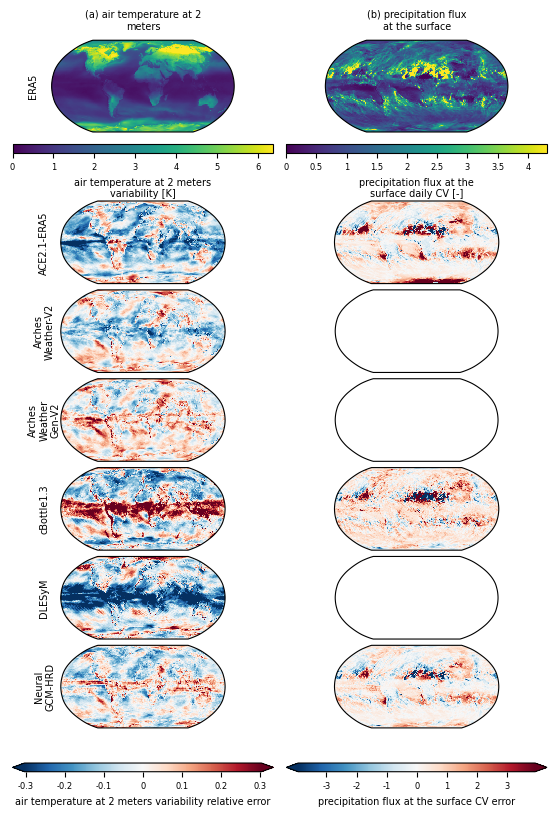

In [76]:
# Manuscript Figure 1: ERA5 daily variability and model error, tas and pr
#
# Layout mirrors E2: rows = ERA5 (row 0) + dummy ERA5-colorbar row + model rows
# columns = tas, pr   |   width = GMD_DOUBLE_COL_IN

import re as _re

def _base_long_name(var):
    """Strip ' daily variability' suffix from ERA5 long_name for concise labels."""
    ln = regridded_1deg_daily_anomaly_std_era5[var].attrs.get('long_name', var).lower().replace('_', ' ')
    suffix = ' daily variability'
    return ln[:-len(suffix)] if ln.endswith(suffix) else ln

def _wrap_row_label(s, min_part=3):
    """Split at CamelCase boundaries for rotated row labels (mirrors E2)."""
    parts = _re.split(r'(?<=[a-z])(?=[A-Z])', s)
    merged = [parts[0]]
    for p in parts[1:]:
        if len(merged[-1]) < min_part or len(p) < min_part:
            merged[-1] += p
        else:
            merged.append(p)
    return '\n'.join(merged)

vars_to_plot = ['tas', 'pr']
VAR_SCALE    = {'tas': 1.0}
VAR_ERA5_UNITS = {
    'tas': regridded_1deg_daily_anomaly_std_era5['tas'].attrs.get('units', 'K'),
}
exp_names     = [e for e in error_1deg.experiment_submission.values if e != "MD1.5"]
n_model_rows  = len(exp_names)
n_cols        = len(vars_to_plot)

map_h      = (GMD_DOUBLE_COL_IN / n_cols) / 1.9
fig_width  = GMD_DOUBLE_COL_IN
fig_height = min((n_model_rows + 1) * map_h * 1.15 + 1.0, GMD_MAX_HEIGHT_IN)

fig = plt.figure(figsize=(fig_width, fig_height))
# Row 0 = ERA5 maps, row 1 = dummy (ERA5 colorbars, compact), rows 2+ = model error maps.
# Dummy row is 0.6x a map row — enough for a horizontal colorbar + 1–2 line label.
height_ratios = [1.0, 0.6] + [1.0] * n_model_rows
gs = fig.add_gridspec(
    nrows=2 + n_model_rows, ncols=n_cols,
    height_ratios=height_ratios,
    hspace=0.08, wspace=0.05,
)
fig.subplots_adjust(top=0.92, left=0.12)

ims_era5_by_var  = {}
ims_err_by_var   = {}
axes_era5_by_var = {var: [] for var in vars_to_plot}
axes_err_by_var  = {var: [] for var in vars_to_plot}
col0_axes        = {}   # gs_row -> ax (col 0), for row labels
top_row_axes     = {}   # col index -> ax (ERA5 row), for column headers

# error_1deg is dimensionless — no VAR_SCALE applied to errors
vlims_err = {}
for var in vars_to_plot:
    all_err = error_1deg[var].median('realization')
    q02     = float(all_err.quantile(0.02))
    q98     = float(all_err.quantile(0.98))
    vlims_err[var] = max(abs(q02), abs(q98))

# ── Row 0: ERA5 daily variability (tas) / daily CV (pr) ─────────────────────
for ci, var in enumerate(vars_to_plot):
    if var == 'pr':
        era5_data = (regridded_1deg_daily_anomaly_std_era5['pr']
                     / regridded_1deg_time_mean_pr_era5['pr'])
    else:
        era5_data = regridded_1deg_daily_anomaly_std_era5[var] * VAR_SCALE.get(var, 1.0)
    era5_vmax = float(era5_data.quantile(0.98))

    ax = fig.add_subplot(gs[0, ci], projection=ccrs.Robinson())
    axes_era5_by_var[var].append(ax)
    top_row_axes[ci] = ax
    if ci == 0:
        col0_axes[0] = ax

    im = era5_data.plot(
        ax=ax, transform=ccrs.PlateCarree(), cmap='viridis',
        vmin=0, vmax=era5_vmax, add_colorbar=False, add_labels=False,
    )
    ims_era5_by_var[var] = im
    ax.set_title('')

# ── Dummy row (gs row 1): invisible axes for ERA5 colorbar placement ─────────
dummy_era5_ax = {}
for ci, var in enumerate(vars_to_plot):
    ax_d = fig.add_subplot(gs[1, ci])
    ax_d.set_visible(False)
    dummy_era5_ax[var] = ax_d

# ── Rows 2+: model error maps ──────────────────────────────────────────────
for ri, exp in enumerate(exp_names):
    gs_row = ri + 2
    for ci, var in enumerate(vars_to_plot):
        ax = fig.add_subplot(gs[gs_row, ci], projection=ccrs.Robinson())
        axes_err_by_var[var].append(ax)
        if ci == 0:
            col0_axes[ri + 1] = ax

        data = error_1deg[var].median('realization').sel(experiment_submission=exp)
        ax.set_title('')
        if bool(data.isnull().all()):
            ax.set_global()
        else:
            im = data.plot(
                ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r',
                vmin=-vlims_err[var], vmax=vlims_err[var],
                add_colorbar=False, add_labels=False,
            )
            ims_err_by_var[var] = im

# ── Model error colorbars below all model rows (placed before canvas.draw) ───
err_cbar_ax = {}
for var in vars_to_plot:
    if var not in ims_err_by_var:
        continue
    base_name = _base_long_name(var)
    if var == 'pr':
        err_label_str = f'{base_name} CV error'
    else:
        err_label_str = f'{base_name} variability relative error'
    cbar = fig.colorbar(
        ims_err_by_var[var], ax=axes_err_by_var[var],
        orientation='horizontal', fraction=0.04, pad=0.06, aspect=30, extend='both',
    )
    cbar.set_label(err_label_str, size=LABEL_FS)
    cbar.ax.tick_params(labelsize=LABEL_FS - 1)
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
    err_cbar_ax[var] = cbar.ax

# ── Force layout so axis positions are accurate ───────────────────────────────
fig.canvas.draw()

# ── ERA5 colorbars placed in the dummy row (mirrors E2) ──────────────────────
for var in vars_to_plot:
    if var not in ims_era5_by_var:
        continue
    base_name = _base_long_name(var)
    pos       = dummy_era5_ax[var].get_position()
    ref_var   = next((v for v in vars_to_plot if v in err_cbar_ax), None)
    cbar_h    = err_cbar_ax[ref_var].get_position().height if ref_var else pos.width / 30
    cbar_ax   = fig.add_axes([pos.x0, pos.y0 + pos.height * 0.75, pos.width, cbar_h])
    cbar = fig.colorbar(ims_era5_by_var[var], cax=cbar_ax, orientation='horizontal')
    if var == 'pr':
        era5_cbar_label = textwrap.fill(f'{base_name} daily CV [-]', width=28)
    else:
        era5_units = VAR_ERA5_UNITS[var]
        era5_cbar_label = textwrap.fill(f'{base_name} variability [{era5_units}]', width=28)
    cbar.set_label(era5_cbar_label, size=LABEL_FS)
    cbar.ax.tick_params(labelsize=LABEL_FS - 1)
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))

# ── Row labels: ERA5 + model names at x=-0.10 on col-0 axes ─────────────────
for ri, label in enumerate(['ERA5'] + exp_names):
    col0_axes[ri].text(
        -0.10, 0.5, _wrap_row_label(label),
        transform=col0_axes[ri].transAxes,
        rotation=90, va='center', ha='center',
        fontsize=LABEL_FS, clip_on=False, multialignment='center',
    )

# ── Column headers with letters, centered above each column (mirrors E1) ─────
for ci, var in enumerate(vars_to_plot):
    pos = top_row_axes[ci].get_position()
    x_center = (pos.x0 + pos.x1) / 2
    letter   = chr(ord('a') + ci)
    fig.text(
        x_center, pos.y1 + 0.01,
        f'({letter}) {textwrap.fill(_base_long_name(var), width=20)}',
        ha='center', va='bottom', fontsize=LABEL_FS,
    )

fig.patch.set_alpha(0.0)
ms_savefig(fig, 'daily_variability_error_1deg_map_tas_pr')
plt.show()

Saved ./figures/manuscript_figures/daily_variability_error_1deg_bar_surface_and_plev.png


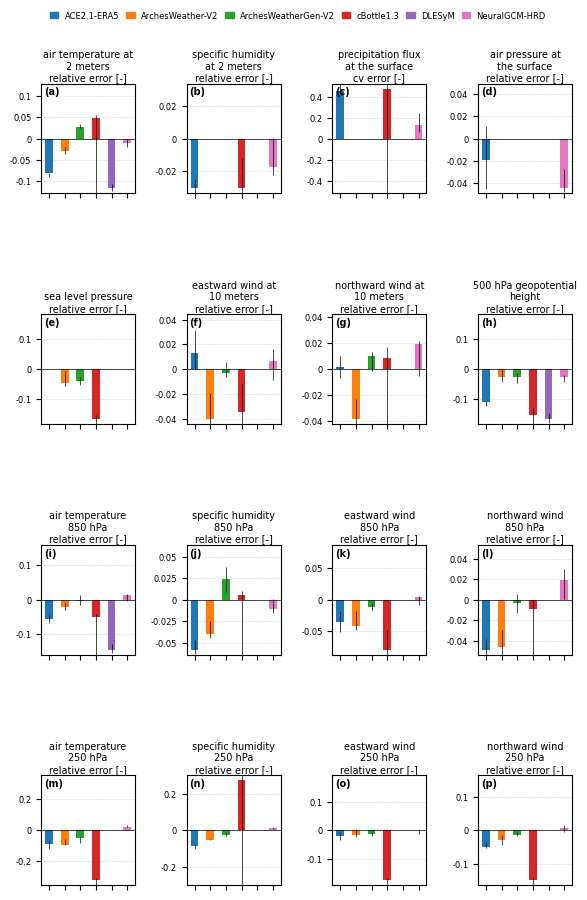

In [77]:
# Manuscript Figure 2: global mean daily variability error, bar chart
# Same 4×4 GRID as E1/E2/E3 bar figures: surface vars × 2 rows + 850 hPa + 250 hPa rows

def _gm_long_name(da, varname):
    """Return cleaned long name, stripping ' daily variability' suffix."""
    ln = da.attrs.get('long_name', varname).lower().replace('_', ' ')
    suffix = ' daily variability'
    return ln[:-len(suffix)] if ln.endswith(suffix) else ln

# Exclude MD1.5 (no daily data); preserve original color ordering for remaining models
_all_exp = list(gm_error_1deg.experiment_submission.values)
exp_submissions_bar = [e for e in _all_exp if e != 'MD1.5']
gm_err = gm_error_1deg.sel(experiment_submission=exp_submissions_bar)
# Colors keyed to original index so omitting MD1.5 doesn't shift subsequent model colors
_bar_colors = [CATEGORICAL_COLORS[_all_exp.index(e)] for e in exp_submissions_bar]

GRID = [
    [('tas', None),  ('huss', None), ('pr', None),   ('ps', None)  ],
    [('psl', None),  ('uas', None),  ('vas', None),  ('zg', None)  ],
    [('ta', 85000.), ('hus', 85000.),('ua', 85000.), ('va', 85000.)],
    [('ta', 25000.), ('hus', 25000.),('ua', 25000.), ('va', 25000.)],
]
NROWS, NCOLS = len(GRID), len(GRID[0])

fig_width  = GMD_DOUBLE_COL_IN
fig_height = GMD_MAX_HEIGHT_IN
fig, axes  = plt.subplots(
    nrows=NROWS, ncols=NCOLS,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace': 0.55, 'hspace': 1.1},
)
fig.subplots_adjust(top=0.91, bottom=0.04)

_tick_fmt       = mticker.FuncFormatter(lambda x, _: f'{x:g}')
legend_handles  = None
panel_letter_i  = ord('a')

for r, row in enumerate(GRID):
    for c, spec in enumerate(row):
        ax = axes[r, c]

        if spec is None:
            ax.set_axis_off()
            continue

        varname, plev = spec
        letter = chr(panel_letter_i)
        panel_letter_i += 1

        if varname not in gm_err:
            ax.set_axis_off()
            ax.text(0.5, 0.5, f'{varname}\nnot available',
                    transform=ax.transAxes, ha='center', va='center', fontsize=LABEL_FS - 1)
            continue

        if plev is not None:
            da = gm_err[varname].sel(plev=plev).drop_vars('plev')
        else:
            da = gm_err[varname]

        da      = da.transpose('experiment_submission', 'realization')
        lowest  = da.min('realization').to_dataframe()[varname]
        median  = da.median('realization').to_dataframe()[varname]
        highest = da.max('realization').to_dataframe()[varname]

        median.plot.bar(
            ax=ax,
            legend=False,
            color=_bar_colors,
            yerr=np.concat(
                [(median - lowest).values[None, :],
                 (highest - median).values[None, :]],
                axis=0,
            ),
            capsize=0,
            error_kw=dict(elinewidth=0.5),
        )
        if legend_handles is None:
            legend_handles, _ = ax.get_legend_handles_labels()

        yscale = max(float(abs(median).max()) * 1.1, 1e-6)
        ax.set_ylim([-yscale, yscale])
        ax.axhline(0, color='k', lw=0.5, zorder=2)
        ax.set_xticklabels([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.yaxis.set_major_formatter(_tick_fmt)
        ax.tick_params(axis='y', labelsize=LABEL_FS - 1)
        ax.yaxis.grid(True, linestyle=':', linewidth=0.4, color='gray', alpha=0.6)
        ax.set_axisbelow(True)

        ax.text(0.03, 0.97, f'({letter})', transform=ax.transAxes,
                fontsize=LABEL_FS, fontweight='bold', va='top', ha='left', zorder=5)

        long_name = _gm_long_name(gm_err[varname], varname)
        if varname == 'zg':
            long_name = textwrap.fill(f'500 hPa {long_name}', width=22)
        else:
            long_name = textwrap.fill(long_name, width=18)
        if plev is not None:
            plev_hpa = int(plev / 100)
            title = f'{long_name}\n{plev_hpa} hPa\n{error_label(varname)}'
        else:
            title = f'{long_name}\n{error_label(varname)}'
        ax.set_title(title, fontsize=LABEL_FS, pad=2)

# Top legend identifying models by color
bar_handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in _bar_colors]
fig.legend(
    bar_handles, exp_submissions_bar,
    fontsize=LABEL_FS - 1,
    loc='upper center',
    ncol=len(exp_submissions_bar),
    bbox_to_anchor=(0.5, 0.995),
    frameon=False,
    borderpad=0.2,
    columnspacing=0.8,
    handlelength=1.0,
)

fig.patch.set_alpha(0.0)
ms_savefig(fig, 'daily_variability_error_1deg_bar_surface_and_plev')
plt.show()
